In [ ]:
!pip install torch_geometric ogb

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv

class VanillaGIN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5):
        super().__init__()

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        for i in range(num_layers):
            layer_in = in_channels if i == 0 else hidden_channels
            layer_out = hidden_channels 

            mlp = nn.Sequential(
                nn.Linear(layer_in, hidden_channels),
                nn.BatchNorm1d(hidden_channels),
                nn.ReLU(),
                nn.Linear(hidden_channels, layer_out)
            )
            
            self.convs.append(GINConv(mlp, train_eps=True))
            
            if i < num_layers - 1:
                self.bns.append(nn.BatchNorm1d(hidden_channels))

        self.post_lp = nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        for i in range(len(self.convs) - 1):
            x = self.convs[i](x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.convs[-1](x, edge_index)
        x = self.post_lp(x)
        return x

In [2]:
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator
from torch_geometric.transforms import ToUndirected, AddSelfLoops, Compose
import time

if not hasattr(torch.load, '_patched'):
    _original_load = torch.load

    def _patched_load(f, **kwargs):
        kwargs["weights_only"] = False
        return _original_load(f, **kwargs)

    _patched_load._patched = True
    torch.load = _patched_load

dataset = PygNodePropPredDataset(
    name='ogbn-arxiv',
    transform=Compose([ToUndirected(), AddSelfLoops()])
)

split_idx = dataset.get_idx_split()
data = dataset[0]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

train_idx = split_idx['train'].to(device)
val_idx   = split_idx['valid'].to(device)
test_idx  = split_idx['test'].to(device)

print(data)
print(f"Device: {device}")
print(f"Num classes: {dataset.num_classes}")

Downloaded 0.08 GB: 100%|██████████| 81/81 [00:03<00:00, 22.42it/s]
Processing...


Extracting dataset/arxiv.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 11335.96it/s]


Converting graphs into PyG objects...


100%|██████████| 1/1 [00:00<00:00, 396.17it/s]

Saving...



Done!


Data(num_nodes=169343, edge_index=[2, 2484941], x=[169343, 128], node_year=[169343, 1], y=[169343, 1])
Device: cuda
Num classes: 40


In [4]:
evaluator = Evaluator(name='ogbn-arxiv')

def train(model, optimizer, criterion):
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)
    loss = criterion(out[train_idx], data.y[train_idx].squeeze())

    loss.backward()
    optimizer.step()

    return loss.item()

@torch.no_grad()
def evaluate(model):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=-1, keepdim=True)

    results = {}
    for split, idx in [('train', train_idx), ('valid', val_idx), ('test', test_idx)]:
        acc = evaluator.eval({
            'y_true': data.y[idx],
            'y_pred': pred[idx]
        })['acc']
        results[split] = acc
    return results

In [15]:
model = VanillaGIN(
    in_channels=dataset.num_features,
    hidden_channels=128,
    out_channels=dataset.num_classes,
    num_layers=3,
    dropout=0.5
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='max',
    factor=0.5,
    patience=20,
)
print(model)
print(f"Num parameters: {sum(p.numel() for p in model.parameters()):,}")

VanillaGIN(
  (convs): ModuleList(
    (0-2): 3 x GINConv(nn=Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=128, bias=True)
    ))
  )
  (bns): ModuleList(
    (0-1): 2 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (post_lp): Linear(in_features=128, out_features=40, bias=True)
)
Num parameters: 105,515


In [16]:
NUM_EPOCHS = 500
patience = 50
counter = 0

best_val_acc = 0
best_test_acc = 0

history = {
    'epoch': [],
    'loss': [],
    'train_acc': [],
    'val_acc': [],
    'test_acc': []
}

for epoch in range(1, NUM_EPOCHS + 1):
    t = time.time()
    loss = train(model, optimizer, criterion)
    elapsed = time.time() - t

    if epoch % 10 == 0:
        results = evaluate(model)

        val_acc = results['valid']
        scheduler.step(val_acc)

        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | "
              f"Train: {results['train']:.4f} | "
              f"Val: {results['valid']:.4f} | "
              f"Test: {results['test']:.4f} | "
              f"Time: {elapsed:.2f}s")

        history['epoch'].append(epoch)
        history['loss'].append(loss)
        history['train_acc'].append(results['train'])
        history['val_acc'].append(results['valid'])
        history['test_acc'].append(results['test'])

        # early stopping logic
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_test_acc = results['test']
            counter = 0
            torch.save(model.state_dict(), 'best_gin_vanilla_node.pt')
        else:
            counter += 10

        if counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch}")
            break

print(f"\nBest Val Acc:  {best_val_acc:.4f}")
print(f"Best Test Acc: {best_test_acc:.4f}")

Epoch 010 | Loss: 3.2263 | Train: 0.2201 | Val: 0.2033 | Test: 0.1949 | Time: 0.24s
Epoch 020 | Loss: 2.8966 | Train: 0.2341 | Val: 0.2334 | Test: 0.2318 | Time: 0.25s
Epoch 030 | Loss: 2.7821 | Train: 0.2513 | Val: 0.2853 | Test: 0.2865 | Time: 0.26s
Epoch 040 | Loss: 2.7335 | Train: 0.2587 | Val: 0.2975 | Test: 0.2938 | Time: 0.26s
Epoch 050 | Loss: 2.6849 | Train: 0.2613 | Val: 0.3067 | Test: 0.3020 | Time: 0.28s
Epoch 060 | Loss: 2.6355 | Train: 0.2637 | Val: 0.3350 | Test: 0.3631 | Time: 0.28s
Epoch 070 | Loss: 2.5757 | Train: 0.2896 | Val: 0.3365 | Test: 0.3412 | Time: 0.27s
Epoch 080 | Loss: 2.4972 | Train: 0.3435 | Val: 0.3933 | Test: 0.3996 | Time: 0.26s
Epoch 090 | Loss: 2.3896 | Train: 0.3711 | Val: 0.4209 | Test: 0.4249 | Time: 0.25s
Epoch 100 | Loss: 2.2753 | Train: 0.3940 | Val: 0.4198 | Test: 0.4037 | Time: 0.24s
Epoch 110 | Loss: 2.2291 | Train: 0.3953 | Val: 0.4304 | Test: 0.4194 | Time: 0.24s
Epoch 120 | Loss: 2.1922 | Train: 0.4081 | Val: 0.4390 | Test: 0.4275 | Time

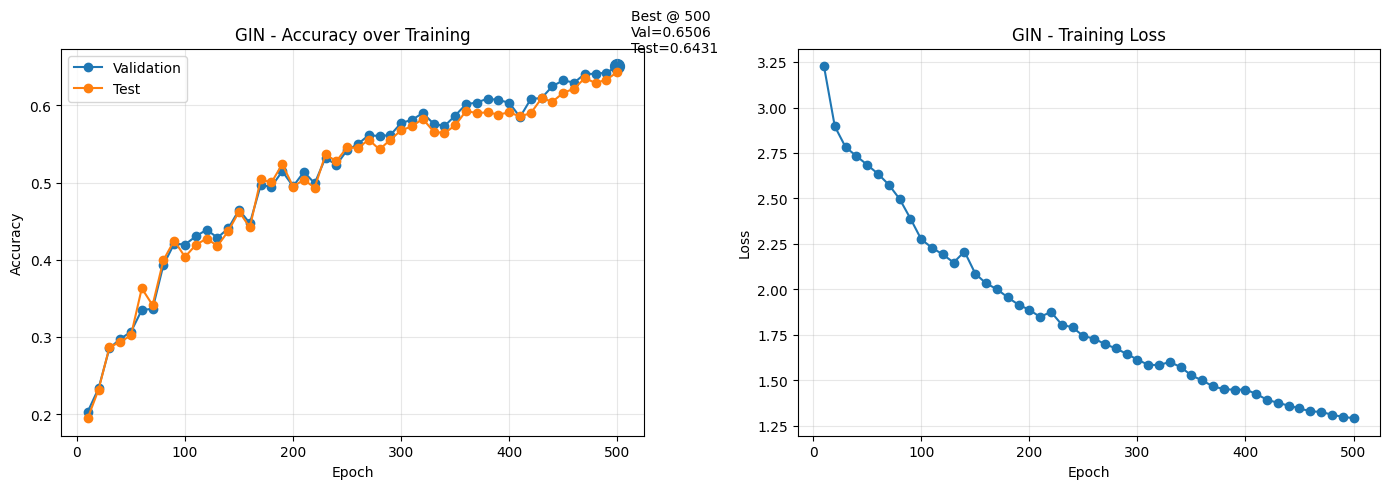

In [17]:
import matplotlib.pyplot as plt

epochs_logged = list(range(10, 501, 10))

val_accs = [
    0.2033, 0.2334, 0.2853, 0.2975, 0.3067, 0.3350, 0.3365, 0.3933, 0.4209, 0.4198,
    0.4304, 0.4390, 0.4287, 0.4406, 0.4648, 0.4473, 0.4964, 0.4949, 0.5147, 0.4952,
    0.5138, 0.4991, 0.5322, 0.5228, 0.5420, 0.5500, 0.5615, 0.5603, 0.5616, 0.5773,
    0.5813, 0.5901, 0.5764, 0.5731, 0.5869, 0.6015, 0.6038, 0.6088, 0.6070, 0.6035,
    0.5849, 0.6084, 0.6096, 0.6250, 0.6325, 0.6295, 0.6409, 0.6409, 0.6426, 0.6506
]

test_accs = [
    0.1949, 0.2318, 0.2865, 0.2938, 0.3020, 0.3631, 0.3412, 0.3996, 0.4249, 0.4037,
    0.4194, 0.4275, 0.4180, 0.4371, 0.4625, 0.4419, 0.5041, 0.5002, 0.5239, 0.4949,
    0.5037, 0.4934, 0.5365, 0.5277, 0.5457, 0.5449, 0.5556, 0.5430, 0.5556, 0.5678,
    0.5729, 0.5827, 0.5662, 0.5640, 0.5742, 0.5927, 0.5902, 0.5910, 0.5882, 0.5910,
    0.5857, 0.5901, 0.6093, 0.6049, 0.6163, 0.6217, 0.6354, 0.6290, 0.6335, 0.6431
]

losses = [
    3.2263, 2.8966, 2.7821, 2.7335, 2.6849, 2.6355, 2.5757, 2.4972, 2.3896, 2.2753,
    2.2291, 2.1922, 2.1480, 2.2085, 2.0870, 2.0331, 2.0018, 1.9566, 1.9160, 1.8881,
    1.8486, 1.8769, 1.8069, 1.7913, 1.7441, 1.7297, 1.6994, 1.6762, 1.6459, 1.6145,
    1.5856, 1.5845, 1.6013, 1.5735, 1.5276, 1.4997, 1.4673, 1.4519, 1.4486, 1.4496,
    1.4260, 1.3931, 1.3772, 1.3610, 1.3465, 1.3296, 1.3273, 1.3112, 1.2997, 1.2926
]

best_idx = val_accs.index(max(val_accs))
best_epoch = epochs_logged[best_idx]
best_val = val_accs[best_idx]
best_test = test_accs[best_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_logged, val_accs, label='Validation', marker='o')
ax1.plot(epochs_logged, test_accs, label='Test', marker='o')

ax1.scatter(best_epoch, best_val, s=100)
ax1.annotate(
    f'Best @ {best_epoch}\nVal={best_val:.4f}\nTest={best_test:.4f}',
    (best_epoch, best_val),
    textcoords="offset points",
    xytext=(10, 10)
)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('GIN - Accuracy over Training')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_logged, losses, marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('GIN - Training Loss')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

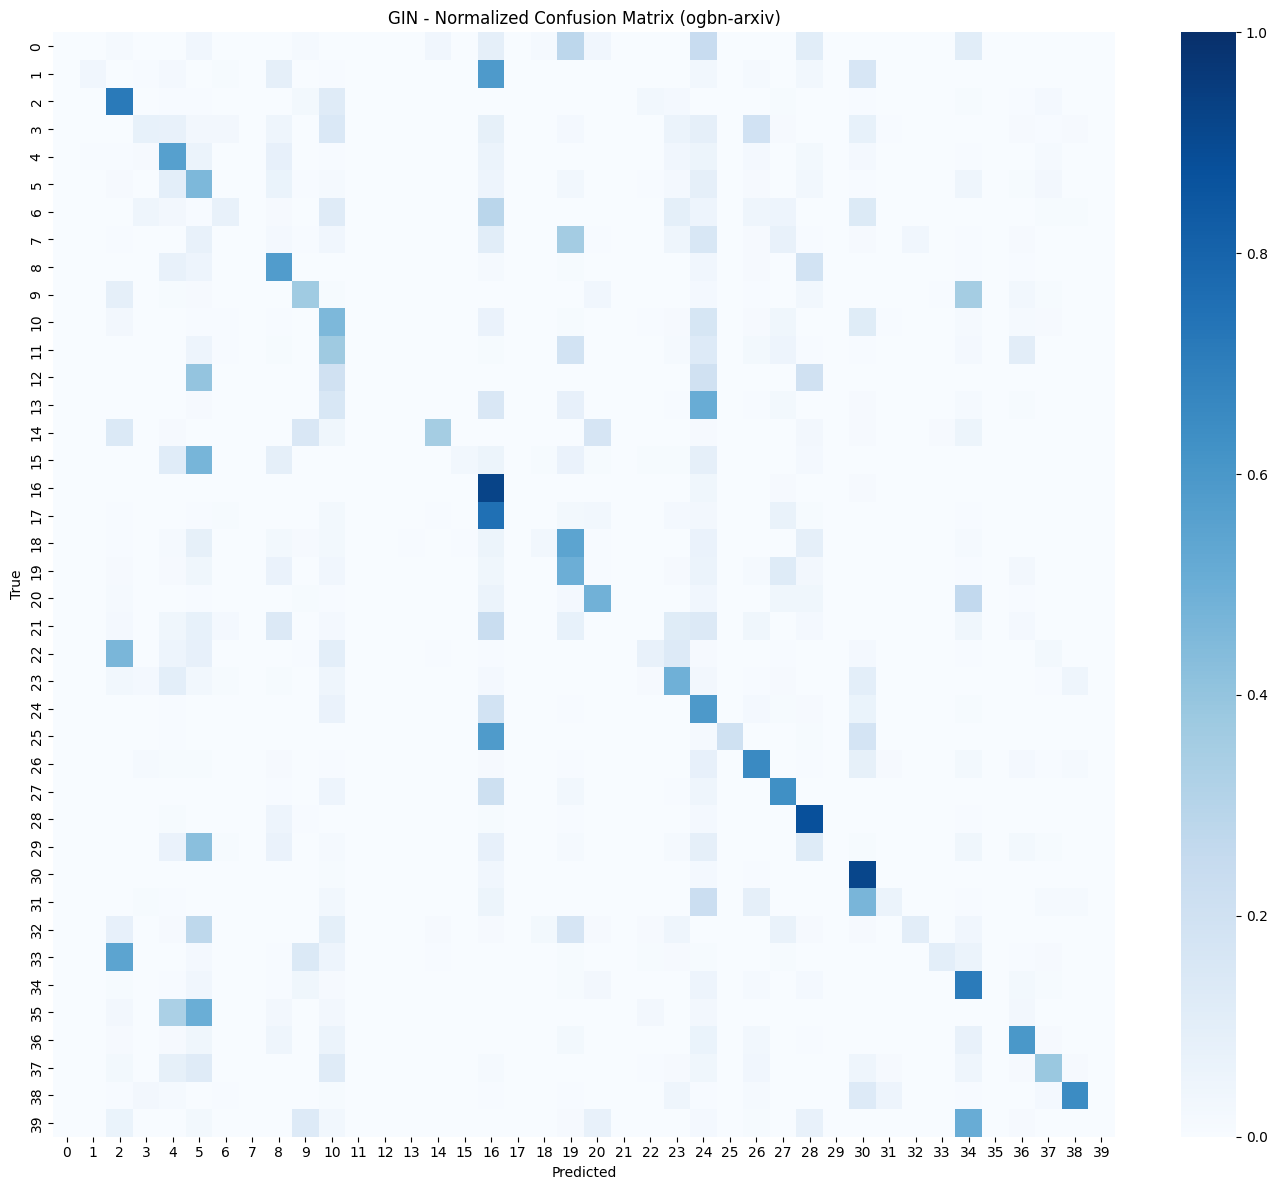

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import os
import torch

if os.path.exists('/kaggle/working/best_gin.pt'):
    model.load_state_dict(torch.load('/kaggle/working/best_gin.pt', map_location=device))
elif os.path.exists('best_gin.pt'):
    model.load_state_dict(torch.load('best_gin.pt', map_location=device))

@torch.no_grad()
def get_test_predictions(model):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=-1)

    test_preds = pred[test_idx].detach().cpu()
    test_labels = data.y[test_idx].squeeze().detach().cpu()
    return test_labels, test_preds

test_labels, test_preds = get_test_predictions(model)

cm = confusion_matrix(test_labels.numpy(), test_preds.numpy(), labels=list(range(dataset.num_classes)))
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_normalized, cmap='Blues', ax=ax, vmin=0, vmax=1)

ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('GIN - Normalized Confusion Matrix (ogbn-arxiv)')

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

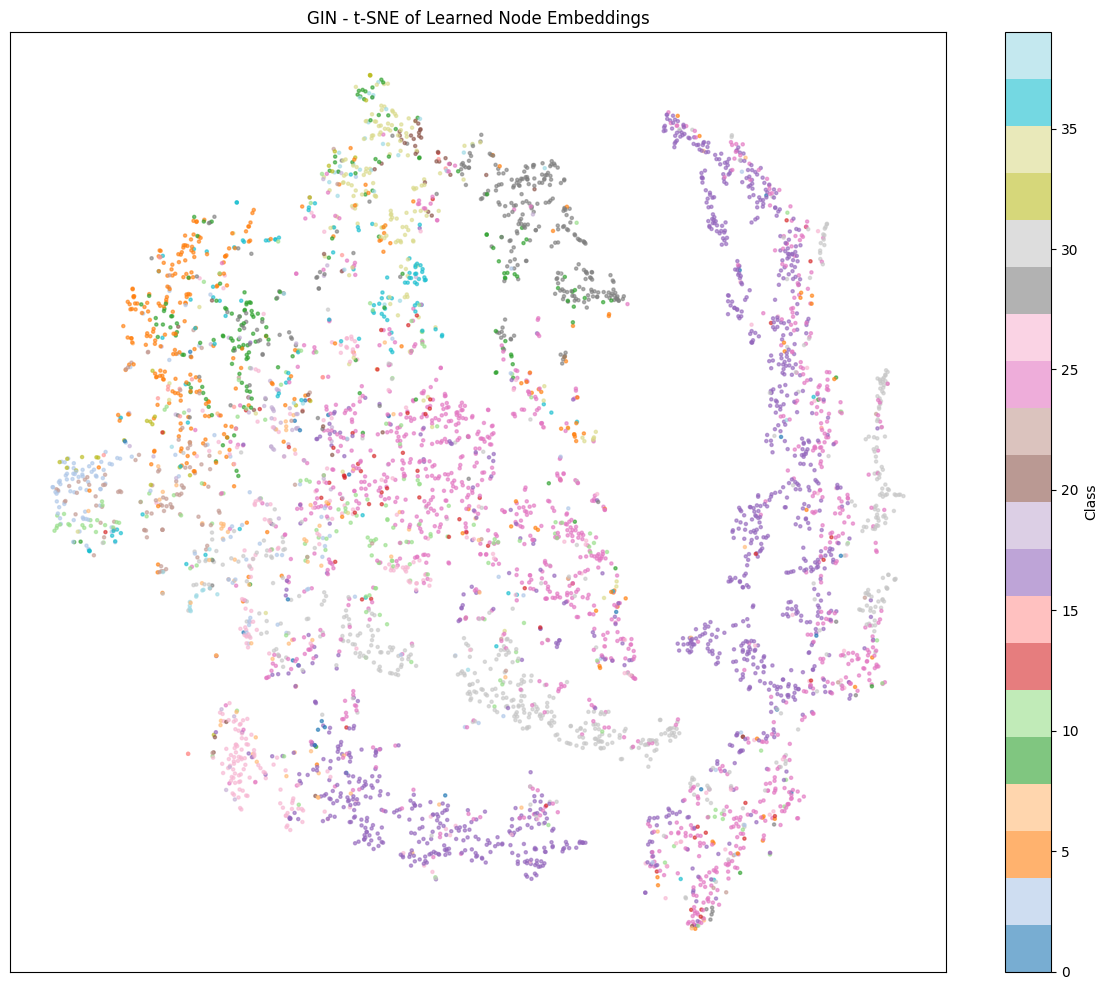

In [19]:
from sklearn.manifold import TSNE
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

if os.path.exists('/kaggle/working/best_gin.pt'):
    model.load_state_dict(torch.load('/kaggle/working/best_gin.pt', map_location=device))
elif os.path.exists('best_gin.pt'):
    model.load_state_dict(torch.load('best_gin.pt', map_location=device))

@torch.no_grad()
def get_embeddings(model):
    model.eval()
    x = data.x
    for i, conv in enumerate(model.convs[:-1]):
        x = conv(x, data.edge_index)
        x = model.bns[i](x)
        x = F.relu(x)
    return x.detach().cpu()

all_embeds = get_embeddings(model)
test_embeds = all_embeds[test_idx.cpu()]
test_labels_for_tsne = data.y[test_idx].squeeze().detach().cpu()

n_samples = min(5000, len(test_embeds))
rng = np.random.default_rng(42)
indices = rng.choice(len(test_embeds), n_samples, replace=False)

embeds_sub = test_embeds[indices].numpy()
labels_sub = test_labels_for_tsne[indices].numpy()

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
embeds_2d = tsne.fit_transform(embeds_sub)

fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(
    embeds_2d[:, 0], embeds_2d[:, 1],
    c=labels_sub,
    cmap='tab20',
    s=5,
    alpha=0.6
)

ax.set_title('GIN - t-SNE of Learned Node Embeddings')
ax.set_xticks([])
ax.set_yticks([])

plt.colorbar(scatter, ax=ax, label='Class')
plt.tight_layout()
plt.savefig('/kaggle/working/tsne_embeddings.png', dpi=150)
plt.show()